In [ ]:
import requests
import base64
import os

from dotenv import load_dotenv
from langchain_groq import ChatGroq

# ---------------------------
# Load Environment Variables
# ---------------------------
load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY not found in .env file")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env file")

# ---------------------------
# Groq LLM
# ---------------------------
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=GROQ_API_KEY
)

# ---------------------------
# OpenRouter Config
# ---------------------------
url = "https://openrouter.ai/api/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
    "Content-Type": "application/json"
}

# ---------------------------
# Main Loop
# ---------------------------
while True:

    user_prompt = input("\nUser Prompt: ")

    if user_prompt.lower() in ["exit", "quit", "q"]:
        print("Exiting...")
        break

    # ---------------------------
    # Step 1: Enhance Prompt
    # ---------------------------
    print("\nEnhancing prompt using Groq...")

    enhanced_prompt = llm.invoke(
        f"""
        You are an expert prompt engineer for AI image generation.

        Convert the user's idea into a highly detailed,
        professional image generation prompt.

        Include:
        - Subject details
        - Environment
        - Composition
        - Camera angle
        - Lighting
        - Colors
        - Artistic style
        - High-quality rendering details

        User Idea:
        {user_prompt}

        Return only the final enhanced prompt.
        """
    ).content

    print("\n" + "=" * 80)
    print("ENHANCED PROMPT")
    print("=" * 80)
    print(enhanced_prompt)

    # ---------------------------
    # Step 2: Generate Image
    # ---------------------------
    payload = {
        "model": "google/gemini-2.5-flash-image",
        "messages": [
            {
                "role": "user",
                "content": enhanced_prompt
            }
        ],
        "modalities": ["text", "image"],
        "max_tokens": 1024
    }

    print("\nGenerating image...")

    response = requests.post(
        url,
        headers=headers,
        json=payload,
        timeout=300
    )

    print("Status Code:", response.status_code)

    result = response.json()

    # ---------------------------
    # Step 3: Handle Errors
    # ---------------------------
    if "error" in result:

        print("\nERROR:")
        print(result["error"])
        continue

    # ---------------------------
    # Step 4: Process Response
    # ---------------------------
    if result.get("choices"):

        message = result["choices"][0]["message"]

        # Optional text response
        if message.get("content"):

            print("\nMODEL RESPONSE:")
            print(message["content"])

        # Extract image
        if message.get("images"):

            for idx, image in enumerate(message["images"], start=1):

                data_url = image["image_url"]["url"]

                base64_str = data_url.split(",", 1)[1]

                image_bytes = base64.b64decode(base64_str)

                filename = f"generated_image_{idx}.png"

                with open(filename, "wb") as f:
                    f.write(image_bytes)

                print(f"\n✅ Image saved as: {filename}")

        else:
            print("\n⚠ No image returned.")

    else:

        print("\nUnexpected response format:")
        print(result)

c:\Users\rawat\Downloads\Data_science_IIT_Guwahati\GenAI\ai_powered_img_gen\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
google/gemini-2.5-flash-image

200
{'id': 'gen-1781775636-oS8G91SD0ri4UVXvybzK', 'object': 'chat.completion', 'created': 1781775636, 'model': 'google/gemini-2.5-flash-image', 'provider': 'Google', 'system_fingerprint': None, 'service_tier': 'default', 'choices': [{'index': 0, 'logprobs': None, 'finish_reason': 'stop', 'native_finish_reason': 'STOP', 'message': {'role': 'assistant', 'content': "Absolutely! Here's a beautiful sunset over mountains for you: ", 'refusal': None, 'reasoning': None, 'images': [{'type': 'image_url', 'image_url': {'url': ''}}]}}], 'usage': {'prompt_tokens': 6, 'completion_tokens': 1304, 'total_tokens': 1310, 'cost': 0.0387368, 'is_byok': False, 'prompt_tokens_details': {'cached_tokens': 0, 'cache_write_tokens': 0, 'audio_tokens': 0, 'video_tokens': 0}, 'cost_details': {'upstream_inference_cost': 0.0387368, 'upstream_inference_prompt_cost': 1.8e-06, 'upstream_inference_completions_cost': 0.038735}, 'completion_tokens_details': {'reasoning_tokens': 0, 'image_tokens': 1290, 'audio_tokens': 0}}}
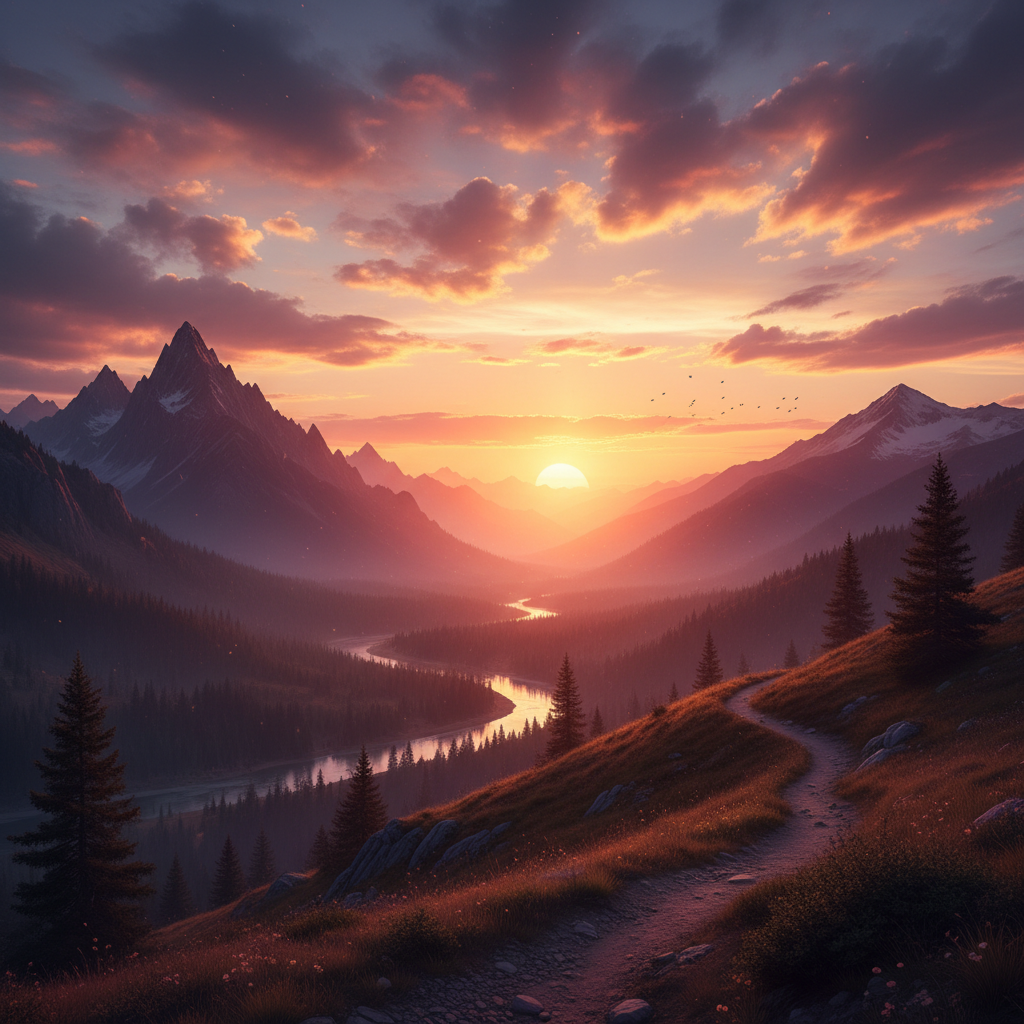

In [3]:
print(response.status_code)
print(result)

{
  "id": "gen-1781775636-oS8G91SD0ri4UVXvybzK",
  "object": "chat.completion",
  "created": 1781775636,
  "model": "google/gemini-2.5-flash-image",
  "provider": "Google",
  "system_fingerprint": null,
  "service_tier": "default",
  "choices": [
    {
      "index": 0,
      "logprobs": null,
      "finish_reason": "stop",
      "native_finish_reason": "STOP",
      "message": {
        "role": "assistant",
        "content": "Absolutely! Here's a beautiful sunset over mountains for you: ",
        "refusal": null,
        "reasoning": null,
        "images": [
          {
            "type": "image_url",
            "image_url": {
              "url": ""
            }
          }
        ]
      }
    }
  ],
  "usage": {
    "prompt_tokens": 6,
    "completion_tokens": 1304,
    "total_tokens": 1310,
    "cost": 0.0387368,
    "is_byok": false,
    "prompt_tokens_details": {
      "cached_tokens": 0,
      "cache_write_tokens": 0,
      "audio_tokens": 0,
      "video_tokens": 0
    
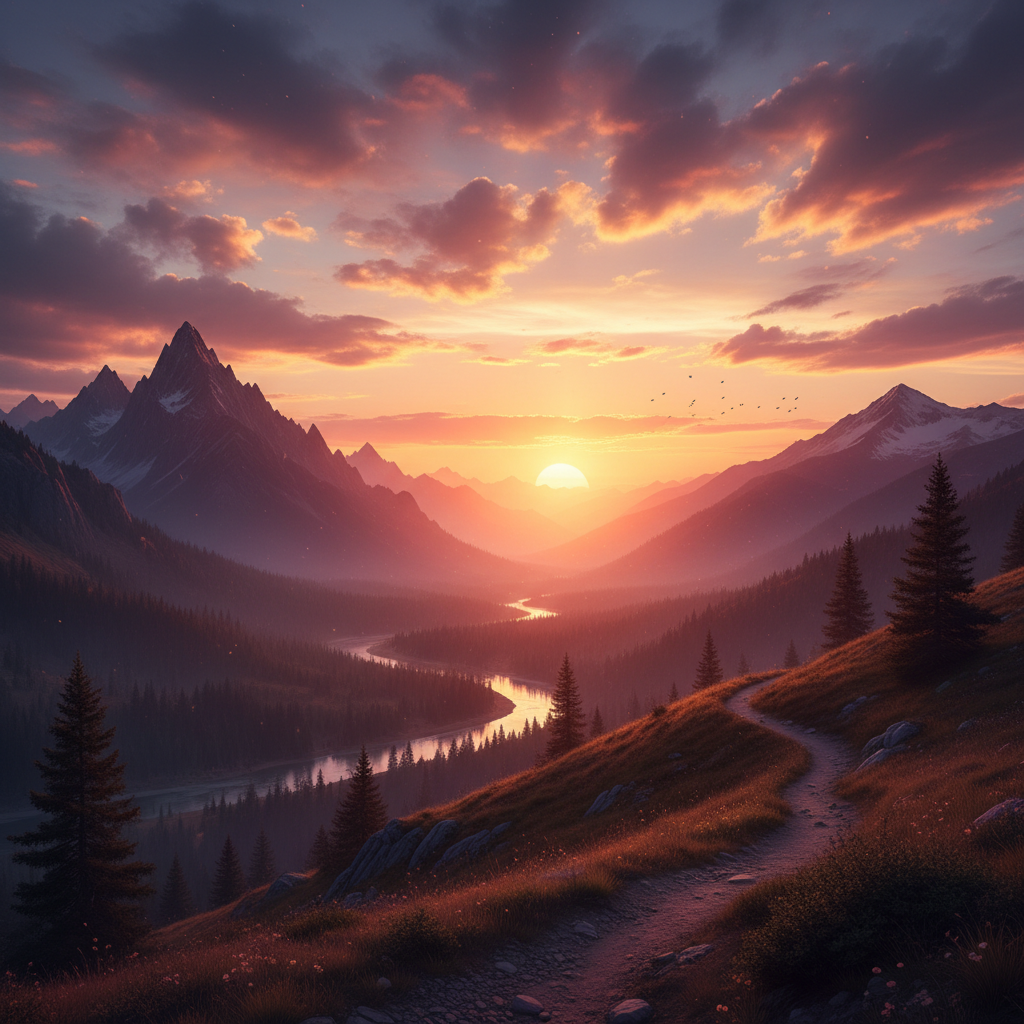

In [4]:
import json

print(json.dumps(result, indent=2))